# Data

In [ ]:
# Download a folder

from huggingface_hub import snapshot_download

# Download only one specific patient folder
snapshot_download(
    repo_id="LMUK-RADONC-PHYS-RES/DoseRAD2026",
    repo_type="dataset",
    allow_patterns="photon/training/1ABB006/*",
    local_dir="./dose_rad_trial"
)
print("Download complete!")


Fetching ... files: 0it [00:00, ?it/s]

In [ ]:
%pip install -q SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.1 MB/s eta 0:00:00


# Combine Dose

In [ ]:
import os
import glob
import re
import numpy as np
import SimpleITK as sitk
from pathlib import Path
from tqdm import tqdm


In [ ]:
ref_image = sitk.ReadImage('/content/dose_rad_trial/photon/training/1ABB006/image/ct.mha')
ref_spacing = ref_image.GetSpacing()
ref_origin = ref_image.GetOrigin()
ref_direction = ref_image.GetDirection()

In [ ]:
accumulated_dose_array = np.zeros(sitk.GetArrayFromImage(ref_image).shape, dtype=np.float32)
dose_file_dir = Path('/content/dose_rad_trial/photon/training/1ABB006/dose')

for filepath in dose_file_dir.iterdir():
    # Load the individual segment dose
    single_dose_img = sitk.ReadImage(filepath)
    single_dose_array = sitk.GetArrayFromImage(single_dose_img)
    accumulated_dose_array += single_dose_array

final_plan_dose_img = sitk.GetImageFromArray(accumulated_dose_array)
final_plan_dose_img.SetSpacing(ref_spacing)
final_plan_dose_img.SetOrigin(ref_origin)
final_plan_dose_img.SetDirection(ref_direction)

# 6. Save the final integrated full-plan map to disk
sitk.WriteImage(final_plan_dose_img, 'dose.mha', useCompression=True)

In [ ]:
!ls -lah

total 9.3M
drwxr-xr-x 1 root root 4.0K Jun 30 11:16 .
drwxr-xr-x 1 root root 4.0K Jun 30 10:44 ..
drwxr-xr-x 4 root root 4.0K Jun  4 13:32 .config
-rw-r--r-- 1 root root 9.2M Jun 30 11:16 dose.mha
drwxr-xr-x 4 root root 4.0K Jun 30 11:11 dose_rad_trial
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [ ]:
!wget https://huggingface.co/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/resolve/main/photon/training/1ABB006/image/ct.mha
!wget https://huggingface.co/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/resolve/main/photon/training/1ABB006/image/mr.mha
!wget https://huggingface.co/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/resolve/main/photon/training/1ABB006/dose/Dose_B0_CP000.mha?download=true
!wget https://huggingface.co/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/resolve/main/photon/training/1ABB006/1ABB006.json

--2026-06-30 05:11:44--  https://huggingface.co/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/resolve/main/photon/training/1ABB006/image/ct.mha
Resolving huggingface.co (huggingface.co)... 3.163.189.37, 3.163.189.114, 3.163.189.90, ...
Connecting to huggingface.co (huggingface.co)|3.163.189.37|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/69d6493854a04b1f8d248724/e06f2b695a179acfcdfef3ca2616106146ed0f64f2a5f7fd8aa60acac672e027?user_id=public&X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27ct.mha%3B+filename%3D%22ct.mha%22%3B&Expires=1782799904&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjlkNjQ5Mzg1NGEwNGIxZjhkMjQ4NzI0L2UwNmYyYjY5NWExNzlhY2ZjZGZlZjNjYTI2MTYxMDYxNDZlZDBmNjRmMmE1ZjdmZDhhYTYwYWNhYzY3MmUwMjdcXD91c2VyX2lkPXB1YmxpYyZYLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPWlubGluZSUzQitmaWxlbmFtZSUyQSUzRFVURi04JTI3

In [ ]:
%pip install -qq SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.2 MB/s eta 0:00:00


# Baseline Code Official
https://github.com/DoseRAD2026/pyradplan-pb-baseline

In [ ]:
%pip install -qq pyRadPlan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 964.0/964.0 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.6/93.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.1/80.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
!wget https://github.com/DoseRAD2026/pyradplan-pb-baseline/raw/refs/heads/main/utils.py

--2026-06-30 11:27:08--  https://github.com/DoseRAD2026/pyradplan-pb-baseline/raw/refs/heads/main/utils.py
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/DoseRAD2026/pyradplan-pb-baseline/refs/heads/main/utils.py [following]
--2026-06-30 11:27:08--  https://raw.githubusercontent.com/DoseRAD2026/pyradplan-pb-baseline/refs/heads/main/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4085 (4.0K) [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]   3.99K  --.-KB/s    in 0s      

2026-06-30 11:27:08 (63.9 MB/s) - ‘utils.py’ saved [4085/4085]



In [ ]:
import json
import logging
from pathlib import Path

from typing import Literal, Optional
from numpy.typing import NDArray

import numpy as np
import SimpleITK as sitk

from pyRadPlan import PhotonPlan, generate_stf, calc_dose_forward
from pyRadPlan.ct import ct_from_file
from pyRadPlan.cst import StructureSet
from pyRadPlan.machines import Jaw, MLC

from utils import DIR_IMAGE, DIR_DOSE, BEAM_PARAMS_FILENAME, CT_NAME, plot_dose_comparison

In [ ]:
# Fixed machine / geometry constants for the photon baseline.
_MC_SCALE       = 19755.0  # weight normalisation matched on central-axis depth-dose curve
_MLC_LEAF_WIDTH = 5.0     # mm
_JAW_HALF       = 200.0   # mm
_ENERGY         = 6.0     # MeV (fixed for the generic photon machine)"

In [ ]:
def _compute_cp_dose(
    ct,
    cst,
    beam_json: dict,
    cp_json: dict,
    hlut: Optional[NDArray] = None,
) -> sitk.Image:
    """Compute pencil-beam dose for a single control point.

    Reconstructs MLC and jaw geometry from the plan JSON, builds a
    field-based STF via pyRadPlan's photon BLD generator, normalises
    beamlet weights to the MC scale, and runs the AAA forward dose engine.

    Returns the dose image (physical_dose).
    """
    iso_center   = np.array(beam_json["iso_center"], dtype=float)
    gantry_angle = float(cp_json["gantry_angle"])
    n_leaf_pairs = int(beam_json["num_mlc_leaf_pairs"])

    # Compared to pyRadPlan's convention, MLC positions seem to be rotated by 180° and shifted by 0.5 mm
    mlc_left  = -np.flip(np.array(cp_json["mlc_right_int_mm"], dtype=float)) + 0.5
    mlc_right = -np.flip(np.array(cp_json["mlc_left_int_mm"], dtype=float)) + 0.5

    leaf_position_boundaries = np.arange(
        -n_leaf_pairs / 2 * _MLC_LEAF_WIDTH,
         n_leaf_pairs / 2 * _MLC_LEAF_WIDTH,
        _MLC_LEAF_WIDTH,
    ) # shape (n_leaf_pairs,)

    mlc = MLC(
        device_orientation="X",
        leaf_position_boundaries=leaf_position_boundaries,
        leaf_positions=np.column_stack([mlc_left, mlc_right]),
        leaf_width=_MLC_LEAF_WIDTH,
        leaf_leakage=0.015,
    )

    jaw_x = Jaw(
        device_orientation="X",
        positions=[-_JAW_HALF, _JAW_HALF],
        field_width=2 * _JAW_HALF,
        leakage=0.015,
    )
    jaw_y = Jaw(
        device_orientation="Y",
        positions=[-_JAW_HALF, _JAW_HALF],
        field_width=2 * _JAW_HALF,
        leakage=0.015,
    )

    pln = PhotonPlan(machine="Generic")
    pln.prop_stf = {
        "gantry_angles": [gantry_angle],
        "couch_angles":  [0.0],
        "iso_center":    iso_center,
        "generator":     "photonSingleBixel",
        "field_based":   True,
        "blds":          [mlc, jaw_x, jaw_y],
        "resolution":    1.0,   # 1 mm mask sampling for accurate leaf-edge rendering
        "energy":        _ENERGY,
    }
    pln.prop_dose_calc = {
        "engine":                "SVDPB",
        "dose_grid":             ct.grid,
        "force_penumbra":        1.8,   # approximated to match MC well
        "force_uniform_fluence": True,  # match uniform rejection sampling
        "geometric_lateral_cutoff": 0.0, # field based dose calculation automatically determine larger calculation cones, so this can be zero here
        "hlut": hlut,
    }

    stf = generate_stf(ct, cst, pln)

    # Normalise beamlet weights to the MC fluence scale.
    for beam in stf.beams:
        for ray in beam.rays:
            for beamlet in ray.beamlets:
                beamlet.weight /= _MC_SCALE

    result   = calc_dose_forward(ct, cst, stf, pln)
    pb_dose: sitk.Image = result["physical_dose"]

    return pb_dose, stf


In [ ]:
# from huggingface_hub import snapshot_download

# # Download only one specific patient folder
# snapshot_download(
#     repo_id="LMUK-RADONC-PHYS-RES/DoseRAD2026",
#     repo_type="dataset",
#     allow_patterns="photon/training/1ABB006/*",
#     local_dir="./dose_rad_trial"
# )
# print("Download complete!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


HTTP Error 504 thrown while requesting GET https://huggingface.co/api/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/tree/main?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSndjbTkwYjI0dmRISmhhVzVwYm1jdk1VRkNRakV4TlM5a2IzTmxMMFJ2YzJWZlFqRXhYMUl4WDB3d0xtMW9ZU0lzSW5SeVpXVmZiMmxrSWpvaU1qZGhPRGc0WVdKa01EbG1PRE5sWVRNMU5tSXdNREl6WkRBM056bGpaR0l4TnpBNE1HWTNPQ0o5OjY0MDAw
Retrying in 1s [Retry 1/5].


KeyboardInterrupt: 

In [ ]:
baseline_dir = "/content/dose_rad_trial"
write_dir = "/content/dose_rad_trial"
baseline_pb_dir=baseline_dir
output_dir=write_dir
patient_id="1ABB006"
modality="photon"
split="training"
show_plots=True
plot_view_slice="axial"
plot_shared_max=True
beam_idx=0
cp_idx=1

In [ ]:
baseline_pb_dir = Path(baseline_pb_dir)

# Fixed path layout expected by the challenge dataset.
ct_path        = baseline_pb_dir / modality / split / patient_id / DIR_IMAGE / CT_NAME
plan_json_path = baseline_pb_dir / modality / split / patient_id / f"{patient_id}.json"
dose_dir       = baseline_pb_dir / modality / split / patient_id / DIR_DOSE

In [ ]:
!wget https://huggingface.co/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/resolve/main/photon/training/beam_parameters.json

--2026-06-30 11:29:29--  https://huggingface.co/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/resolve/main/photon/training/beam_parameters.json
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.121, 13.35.202.97, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: /api/resolve-cache/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/e2b0a7cd81a17b21fd2568dae9b4d5f9a2883eab/photon%2Ftraining%2Fbeam_parameters.json?%2Fdatasets%2FLMUK-RADONC-PHYS-RES%2FDoseRAD2026%2Fresolve%2Fmain%2Fphoton%2Ftraining%2Fbeam_parameters.json=&etag=%22b2dc4f7dedbb0fceb7867b88ef098fdebe1cdc9b%22 [following]
--2026-06-30 11:29:29--  https://huggingface.co/api/resolve-cache/datasets/LMUK-RADONC-PHYS-RES/DoseRAD2026/e2b0a7cd81a17b21fd2568dae9b4d5f9a2883eab/photon%2Ftraining%2Fbeam_parameters.json?%2Fdatasets%2FLMUK-RADONC-PHYS-RES%2FDoseRAD2026%2Fresolve%2Fmain%2Fphoton%2Ftraining%2Fbeam_parameters.json=&

In [ ]:
!mv beam_parameters.json dose_rad_trial/

In [ ]:
# General beam parameters
beam_params_json_path = baseline_pb_dir / BEAM_PARAMS_FILENAME
with open(beam_params_json_path) as f:
    beam_params = json.load(f)

In [ ]:
hlut_entries = beam_params["hu_to_density"]["entries"]
hlut_array = np.array([tuple(each.values()) for each in hlut_entries], dtype=float)

In [ ]:
ct_path

PosixPath('/content/dose_rad_trial/photon/training/1ABB006/image/ct.mha')

In [ ]:
ct = ct_from_file(ct_path)

In [ ]:
with open(plan_json_path) as f:
    pln_json = json.load(f)

In [ ]:
# An empty structure set is sufficient for forward dose calculation;
# body segmentation is created automatically from the CT HU values.
cst = StructureSet(vois=[], ct_image=ct)
cst.create_body_seg(voi_type="TARGET")

In [ ]:
# Select the requested beam and control point by their list positions.
beam_json    = pln_json["beams"][beam_idx]
cp_json      = beam_json["control_points"][cp_idx]

In [ ]:
# Read back the plan-internal IDs used in the reference dose filenames.
b_idx        = beam_json["beam_idx"]
c_idx        = cp_json["cp_idx"]
gantry_angle = float(cp_json["gantry_angle"])

In [ ]:
pb_dose, stf = _compute_cp_dose(ct, cst, beam_json, cp_json, hlut=hlut_array)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]/usr/local/lib/python3.12/dist-packages/pyRadPlan/raytracer/_siddon.py:359: RuntimeWarning: divide by zero encountered in divide
  (p_min - self._source_points) / self._ray_vec,  # alpha to "near" plane
/usr/local/lib/python3.12/dist-packages/pyRadPlan/raytracer/_siddon.py:360: RuntimeWarning: divide by zero encountered in divide
  (p_max - self._source_points) / self._ray_vec,
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1452: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/usr/local/lib/python3.12/dist-packages/pyRadPlan/raytracer/_siddon.py:429: RuntimeWarning: invalid value encountered in multiply
  ijk = sp_scaled[:, :, None] + rv_scaled[:, :, None] * alphas_mid[:, None, :]

Ray:   0%|          | 0/1 [00:00<?, ?r/s]

Calculating custom kernel interpolators for ray  0



Ray: 100%|██████████| 1/1 [00:01<00:00,  1.37s/r]


In [ ]:
stf.beams[0]

Beam(gantry_angle=-178.0, couch_angle=0.0, bixel_width=5, radiation_mode='photons', machine='Generic', sad=1000.0, iso_center=array([-46.84718448,  27.77766326, -28.13538836]), rays=[Ray(beamlets=[FieldShapeComposite(energy=6.0, num_particles_per_mu=1000000.0, min_mu=0.0, max_mu=inf, relative_fluence=1.0, weight=5.062009617818274e-05, range_shifter=RangeShifter(id=0, eq_thickness=0.0, source_rashi_distance=0.0), focus_ix=0, is_field_based=True, resolution=0.5, grid=array([-200. , -199.5, -199. , -198.5, -198. , -197.5, -197. , -196.5,
       -196. , -195.5, -195. , -194.5, -194. , -193.5, -193. , -192.5,
       -192. , -191.5, -191. , -190.5, -190. , -189.5, -189. , -188.5,
       -188. , -187.5, -187. , -186.5, -186. , -185.5, -185. , -184.5,
       -184. , -183.5, -183. , -182.5, -182. , -181.5, -181. , -180.5,
       -180. , -179.5, -179. , -178.5, -178. , -177.5, -177. , -176.5,
       -176. , -175.5, -175. , -174.5, -174. , -173.5, -173. , -172.5,
       -172. , -171.5, -171. , -1

In [ ]:
for beam in stf.beams:
    source_positions = beam.source_positions

    cp0_source = source_positions[0] # Returns [X, Y, Z] in mm

    print(cp0_source)


AttributeError: 'Beam' object has no attribute 'source_positions'

In [ ]:
# Load the Monte-Carlo ground-truth dose for this control point.
ref_path = dose_dir / f"Dose_B{b_idx}_CP{c_idx:03d}.mha"
ref_dose: sitk.Image = sitk.ReadImage(str(ref_path))

In [ ]:
pb_dose

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x7a97e92400b0> >

In [ ]:
if output_dir is not None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # construct filename
    filename = f"{patient_id}_{modality}_{split}_PB_Dose_B{b_idx}_CP{c_idx:03d}.mha"
    write_path = output_dir / filename

    sitk.WriteImage(pb_dose, str(write_path), useCompression=True)
    logger.info("  PB dose written: %s", write_path)

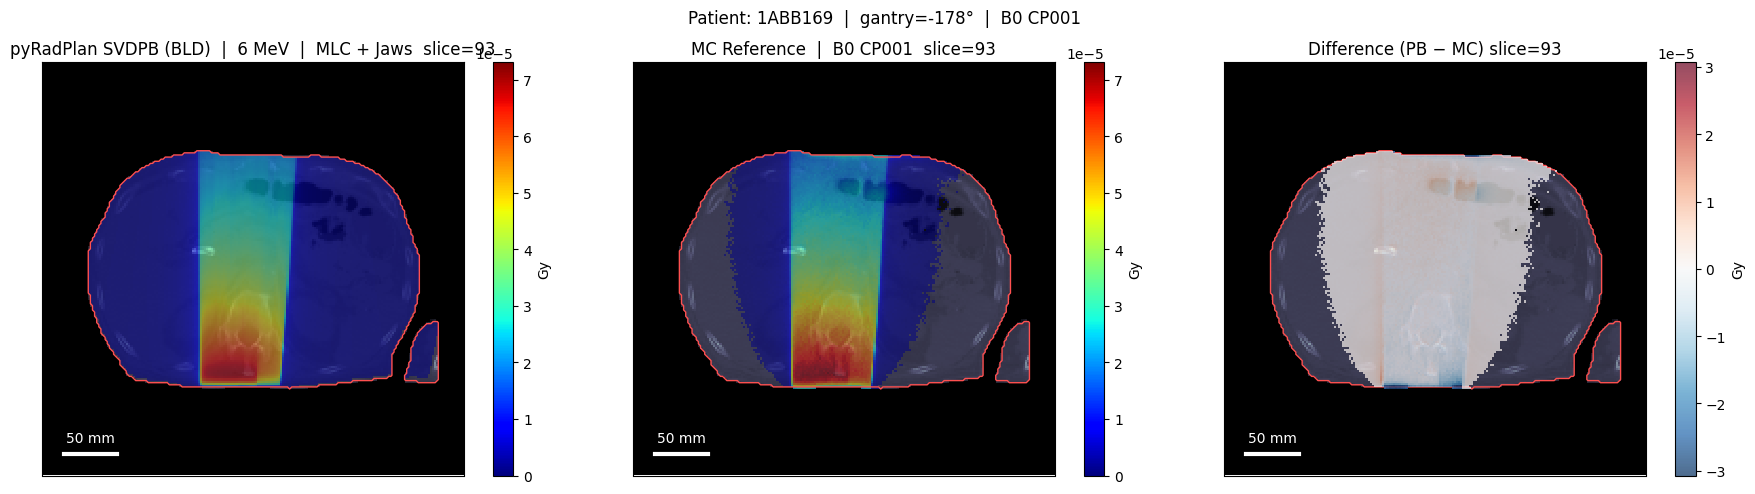

In [ ]:
if show_plots:
    plot_dose_comparison(
        ct=ct, cst=cst,
        pb_dose=pb_dose, ref_dose=ref_dose,
        pb_title=f"pyRadPlan SVDPB (BLD)  |  {_ENERGY:.0f} MeV  |  MLC + Jaws",
        ref_title=f"MC Reference  |  B{b_idx} CP{c_idx:03d}",
        suptitle=(
            f"Patient: {patient_id}  |  gantry={gantry_angle:.0f}°  |  "
            f"B{b_idx} CP{c_idx:03d}"
        ),
        plane=plot_view_slice,
        use_shared_max=plot_shared_max,
    )